# A stress field: a tensor at every node

A fault-slip inversion takes a set of faults with the slip observed on them and
returns the reduced stress tensor that best explains them. It assumes, as it
must, that one tensor explains all of them — that the whole dataset belongs to
one tectonic phase in one place.

That assumption fails routinely. Two phases superposed in time, or one regional
field perturbed near a large structure, and a single inversion returns a tensor
belonging to neither: the mean of two answers is not an answer.

A **stress field** drops the assumption. Every fault contributes to every node
it can reach, by an amount that falls off with distance, and each node is
inverted on its own weighted neighbourhood. Where the data are dense the
estimate is local; where they thin out the same kernel reaches further into
what there is, and the output says how much reached. This is Hardebeck and
Michael's (2006) spatially varying inversion in kernel form.

The notebook builds its own data, so the right answer is known independently of
the search. `01_kernel_density.ipynb` covers the kernel and the grid; this one
assumes them.

## Faults with a known answer

`solve_stress` is the forward model: give it a tensor and a plane and it
predicts the slip. Running it over a spread of orientations manufactures a
fault set that a given tensor explains exactly — which is the only case where
what the inversion should return is known without trusting the inversion.

A few degrees of scatter are added so the misfit is a number rather than zero.
Note *where* they are added: to the **rake**, the angle of the lineation within
its own plane. Perturbing the trend and plunge instead would lift the lineation
off the plane it was recorded on, and misah refuses such a row by name — a
lineation off its plane is not a fault with a small error, it is two
measurements that do not belong to each other.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

from misah.kernels import (covering_grid, density_field, field_cost,
                           invert_stress, rake_to_slickenline, solve_stress,
                           stress_field)

rng = np.random.default_rng(4)

# S1 trend, S1 plunge, S3 trend, S3 plunge, Phi.
EXTENSION   = (0.0, 90.0, 90.0, 0.0, 0.5)   # Andersonian normal: S1 vertical
TRANSCURRENT = (0.0, 0.0, 90.0, 0.0, 0.5)   # strike-slip: S1 and S3 horizontal


def faults_obeying(tensor, count, scatter_degrees=0.0):
    """(N, 4) rows of strike, dip, slickenline trend and plunge."""

    rows = []
    while len(rows) < count:

        strike = rng.uniform(0.0, 360.0)
        dip = rng.uniform(25.0, 85.0)

        solution = solve_stress(*tensor, strike, dip)
        rake = solution["theoretical_rake"]
        if rake is None:
            # The plane lies on a principal axis: no slip is predicted, so
            # there is nothing to invert this one against.
            continue

        # The scatter goes on the *rake* and the lineation is rebuilt from it.
        # Perturbing the trend and plunge directly would lift the lineation off
        # the plane it is recorded on, and misah refuses that by name -- a
        # lineation off its plane is not a fault with a small error, it is two
        # measurements that do not belong to each other. Rake is the coordinate
        # the error actually lives in.
        rake += rng.normal(0.0, scatter_degrees)

        trend, plunge = rake_to_slickenline(strike, dip, rake)
        rows.append([strike, dip, trend, plunge])

    return np.array(rows)


print(faults_obeying(EXTENSION, 3))

[[339.50019801  55.67965317  98.29539069  52.08141517]
 [ 29.1009686   61.44134992  72.58348887  51.65761932]
 [288.68443451  35.47166897  41.2211769   33.350228  ]]


## Two phases, and what one inversion makes of them

A transect twenty kilometres long across a domain boundary. West of the line
the faults obey extension, east of it transcurrence, and nothing marks the line
on the ground: the only thing that changes is which tensor the slip agrees
with.

Deliberately a boundary and not two separated islands. Two clusters far apart
are the easy case — no kernel ever sees both, and every node gets a clean
answer. A boundary puts a band of nodes in the position of seeing both phases
at once, which is where a field is actually at risk of misleading you, and
where the columns further down earn their place.

In [2]:
BOUNDARY = 12_000.0     # easting of the domain boundary, metres

positions = np.column_stack([
    rng.uniform(1_500.0, 22_500.0, size=180),
    rng.normal(10_000.0, 2_500.0, size=180),
])

extensional = positions[:, 0] < BOUNDARY

faults = np.vstack([
    faults_obeying(EXTENSION if west else TRANSCURRENT, 1, scatter_degrees=4.0)
    for west in extensional
])

print(f"{len(faults)} faults over "
      f"{np.ptp(positions[:, 0]) / 1000:.0f} by {np.ptp(positions[:, 1]) / 1000:.0f} km")
print(f"{extensional.sum()} extensional, {(~extensional).sum()} transcurrent")

whole = invert_stress(faults)
print()
print("one inversion over everything")
print(f"  S1                 trend {whole['best']['s1'][0]:6.1f}  plunge {whole['best']['s1'][1]:5.1f}")
print(f"  Phi                {whole['best']['phi']:.2f}")
print(f"  mean misfit        {whole['best']['mean_misfit_degrees']:.1f} degrees")
print()
print("the two truths were  S1 plunge 90 (extension) and S1 plunge 0 (strike-slip)")

180 faults over 21 by 14 km
82 extensional, 98 transcurrent



one inversion over everything
  S1                 trend  180.0  plunge   0.0
  Phi                0.90
  mean misfit        29.2 degrees

the two truths were  S1 plunge 90 (extension) and S1 plunge 0 (strike-slip)


Look at what happened. The search did not return a compromise between
the two phases — it returned one of them, cleanly, and threw the other away.
S1 comes back horizontal, which is the transcurrent answer, and half the
dataset is simply being fitted badly.

Nothing in the orientation says so. The only sign is the **misfit**: a mean of
twenty-odd degrees where a consistent dataset with four degrees of scatter
should give about four. A tensor and a shape ratio, both plausible, both
reported to two decimal places, describing rock that exists on one side of the
map only.

You might hope the runners-up would give it away. They do not:

In [3]:
best_s1 = np.array(whole["best"]["s1"])
print(f"best      S1 {best_s1[0]:6.1f} / {best_s1[1]:5.1f}   "
      f"misfit {whole['best']['mean_misfit_degrees']:5.1f}")
for runner in whole["runners_up"]:
    print(f"runner-up S1 {runner['s1'][0]:6.1f} / {runner['s1'][1]:5.1f}   "
          f"misfit {runner['mean_misfit_degrees']:5.1f}")

best      S1  180.0 /   0.0   misfit  29.2
runner-up S1    0.0 /   0.0   misfit  29.2
runner-up S1  180.0 /  10.0   misfit  29.3
runner-up S1    0.0 /   0.0   misfit  29.3
runner-up S1  180.0 /   0.0   misfit  29.3
runner-up S1  180.0 /  10.0   misfit  29.3


The runners-up are clustered tightly around the winner at essentially
the same misfit. That is what a **well-determined minimum** looks like, and it
is well determined: the search really has found the best single tensor for this
dataset, and it is confident about it.

Which is the lesson. Runners-up tell you how sharp the minimum is. They do not
tell you whether the model — one tensor, everywhere — was the right model. Only
the misfit does that here, and only if you are reading it.

## Size the field before running it

A node costs an exhaustive search — every candidate tensor on the search grid
resolved onto every fault within reach. That is expensive, and how expensive
depends on the data rather than on the grid alone: a compact kernel means each
node sees its own neighbourhood, so a dataset clustered in one corner of its
grid costs far less than one spread evenly.

`field_cost` walks the same nodes with the same kernel and counts. It is not an
estimate from a formula; it does the cheap half of the real thing.

In [4]:
BANDWIDTH = 3_500.0     # metres. The scale the field is smoothed over.
MIN_SUPPORT = 12.0      # effective sample size below which a node is left alone

grid = covering_grid(positions, spacing=[1_500.0, 1_500.0], margin=BANDWIDTH)
print("grid:", grid["counts"], "=", grid["node_count"], "nodes")

start = time.perf_counter()
cost = field_cost(positions, faults,
                  grid["origin"], grid["spacing"], grid["counts"],
                  [BANDWIDTH] * 2,
                  min_support=MIN_SUPPORT)
elapsed = time.perf_counter() - start

print(f"\ncosted in {elapsed * 1000:.1f} ms")
for key, value in cost.items():
    print(f"  {key:20} {value:,}")

# A few million forward solutions a second per core is the order of magnitude.
print(f"\nrough estimate: {cost['forward_solutions'] / 4.5e6:.0f} core-seconds")

grid: [19, 15] = 285 nodes

costed in 0.9 ms
  nodes                285
  nodes_to_invert      64
  forward_solutions    154,036,080

rough estimate: 34 core-seconds


Note how much smaller `forward_solutions` is than a first guess. Not
every node is inverted — the ones no fault reaches, and the ones whose support
falls short, are skipped — and those that are see a few dozen faults rather
than all 180.

## The field

In [5]:
start = time.perf_counter()

field, stats = stress_field(
    positions, faults,
    origin=grid["origin"],
    spacing=grid["spacing"],
    counts=grid["counts"],
    bandwidth=[BANDWIDTH] * 2,
    kernel="quartic",
    min_support=MIN_SUPPORT,
)

print(f"ran in {time.perf_counter() - start:.1f} s across every available core")
print()
for key, value in stats.items():
    print(f"  {key:24} {value}")
print()
print("columns:", ", ".join(field))

ran in 7.9 s across every available core

  nodes                    285
  nodes_inverted           64
  nodes_below_threshold    130
  nodes_without_data       91
  grid_origin              [-1827.5097729346733, -833.8871349943402]
  grid_spacing             [1500.0, 1500.0]
  grid_counts              [19, 15]

columns: positions, density, support, faults_within_reach, has_solution, s1, s2, s3, phi, misfit_degrees, faults_scored, effective_sample_size, runner_up_misfit_degrees, runner_up_s1_degrees


Every column is one entry per node, in the grid's flat order — first axis
fastest — so they line up with each other and with `density_field` on the same
grid.

## Reading it: `support`, not the count

Two columns say how much data reached a node, and they are not the same thing.

- `faults_within_reach` counts the faults that reached at all, at any weight.
- `support` is Kish's effective sample size, `(Σw)² / Σw²`. Twenty faults at
  equal weight give twenty. Twenty of which nineteen sit on the far edge of the
  kernel give barely one.

`support` is the number to read beside a tensor, and the one `min_support` is
applied to. At the edge of a field most nodes are the second kind.

In [6]:
inverted = field["has_solution"]

print(f"{inverted.sum()} of {stats['nodes']} nodes carry a tensor\n")
print(f"{'count':>7} {'support':>9}   where")
for flat in np.argsort(-field["faults_within_reach"])[:4]:
    print(f"{field['faults_within_reach'][flat]:7d} {field['support'][flat]:9.1f}"
          f"   {field['positions'][flat]}")
for flat in np.argsort(field["support"][inverted])[:2]:
    index = np.flatnonzero(inverted)[flat]
    print(f"{field['faults_within_reach'][index]:7d} {field['support'][index]:9.1f}"
          f"   {field['positions'][index]}  <- thinnest node that still qualified")

64 of 285 nodes carry a tensor

  count   support   where
     51      27.8   [11672.49022707  9666.11286501]
     50      30.7   [10172.49022707  9666.11286501]
     47      27.3   [11672.49022707 11166.11286501]
     47      25.7   [14672.49022707 11166.11286501]
     22      12.0   [14672.49022707 14166.11286501]  <- thinnest node that still qualified
     24      12.2   [13172.49022707 14166.11286501]  <- thinnest node that still qualified


## The map

S1 as a tick at each node, over the fault density. Nodes without a tensor are
left blank rather than filled — a field is entitled to holes, and a hole that
is drawn as a hole is information.

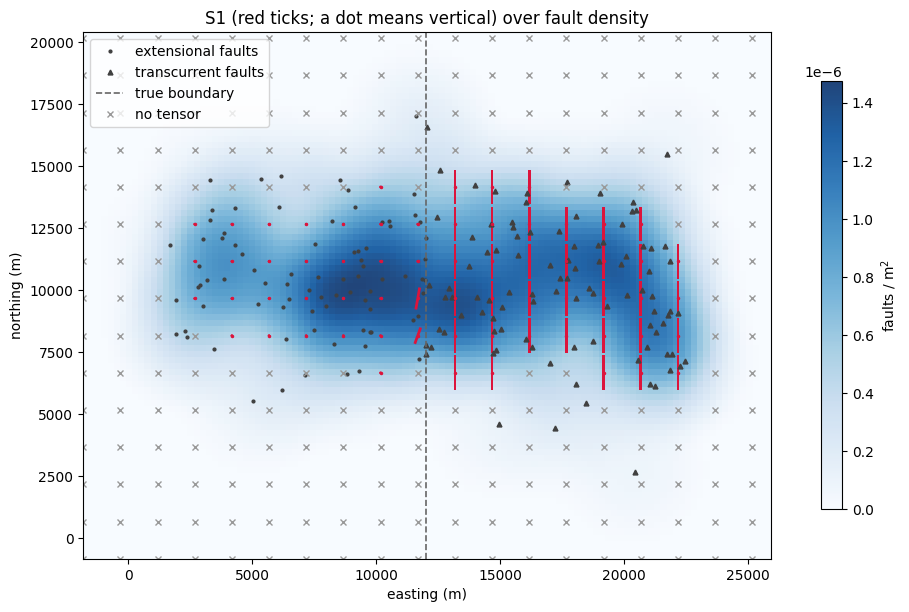

In [7]:
# A finer density grid than the stress grid: density costs microseconds a node
# and a tensor costs a fraction of a second, so there is no reason to look at
# the data through the coarse one.
fine = covering_grid(positions, spacing=[250.0, 250.0], margin=BANDWIDTH)
backdrop = density_field(positions, fine["origin"], fine["spacing"],
                         fine["counts"], [BANDWIDTH] * 2).reshape(fine["counts"], order="F")

extent = [fine["origin"][0],
          fine["origin"][0] + (fine["counts"][0] - 1) * fine["spacing"][0],
          fine["origin"][1],
          fine["origin"][1] + (fine["counts"][1] - 1) * fine["spacing"][1]]

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
im = ax.imshow(backdrop.T, origin="lower", extent=extent, cmap="Blues", alpha=0.9)
fig.colorbar(im, ax=ax, label="faults / m$^2$", shrink=0.8)

ax.plot(positions[extensional, 0], positions[extensional, 1], ".",
        color="0.25", ms=4, label="extensional faults")
ax.plot(positions[~extensional, 0], positions[~extensional, 1], "^",
        color="0.25", ms=3.5, label="transcurrent faults")
ax.axvline(BOUNDARY, color="0.4", ls="--", lw=1.2, label="true boundary")

# S1 as a tick: azimuth from the trend, length from the plunge, so a vertical
# S1 collapses to a dot. Trend is measured clockwise from north.
nodes = field["positions"][inverted]
trend = np.radians(field["s1"][inverted, 0])
plunge = np.radians(field["s1"][inverted, 1])

half = 700.0 * np.cos(plunge)
dx, dy = half * np.sin(trend), half * np.cos(trend)

ax.quiver(nodes[:, 0], nodes[:, 1], dx, dy, angles="xy", scale_units="xy", scale=1,
          headwidth=1, headlength=0, headaxislength=0, width=0.004, color="crimson")
ax.quiver(nodes[:, 0], nodes[:, 1], -dx, -dy, angles="xy", scale_units="xy", scale=1,
          headwidth=1, headlength=0, headaxislength=0, width=0.004, color="crimson")
ax.plot(nodes[:, 0], nodes[:, 1], ".", color="crimson", ms=3)

blank = field["positions"][~inverted]
ax.plot(blank[:, 0], blank[:, 1], "x", color="0.6", ms=5, label="no tensor")

ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
ax.set_title("S1 (red ticks; a dot means vertical) over fault density")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

The western nodes carry dots — S1 vertical, extension. The eastern ones
carry ticks — S1 horizontal, transcurrence. Neither phase was told where it
was, and no boundary was handed to the field; the geography did it.

Read the **plunge** rather than the trend where S1 is steep. The trend of a
vertical axis is undetermined, so a map of S1 trend alone will show a
meaningless rotation across any normal-faulting region.

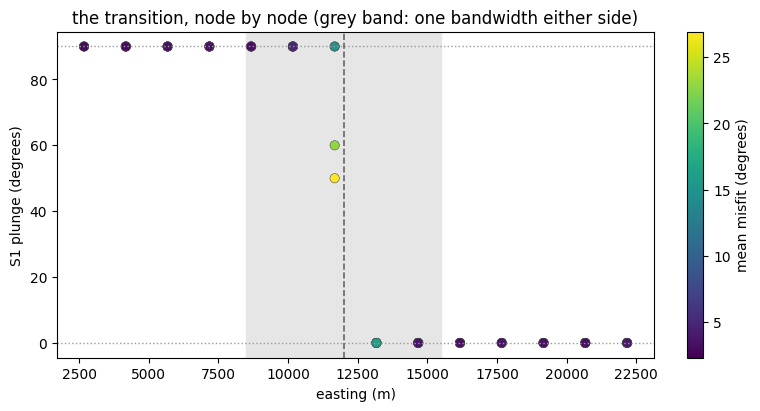

In [8]:
plunge = field["s1"][inverted, 1]
easting = field["positions"][inverted, 0]

fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
scatter = ax.scatter(easting, plunge, c=field["misfit_degrees"][inverted],
                     cmap="viridis", s=45, edgecolor="0.3", linewidth=0.4)
fig.colorbar(scatter, ax=ax, label="mean misfit (degrees)")
ax.axhline(90, ls=":", color="0.6", lw=1)
ax.axhline(0, ls=":", color="0.6", lw=1)
ax.axvline(BOUNDARY, color="0.4", ls="--", lw=1.2)
ax.axvspan(BOUNDARY - BANDWIDTH, BOUNDARY + BANDWIDTH, color="0.9", zorder=0)
ax.set_xlabel("easting (m)")
ax.set_ylabel("S1 plunge (degrees)")
ax.set_title("the transition, node by node (grey band: one bandwidth either side)")
plt.show()

S1 goes over from vertical in the west to horizontal in the east, and it
does so inside the grey band — the nodes within one bandwidth of the true
boundary, which are exactly the nodes whose kernel reaches into both domains.

Two things are worth noticing. The field recovers the boundary it was never
told about, to within the smoothing length it was given: you cannot locate a
boundary more sharply than the bandwidth, and it does not pretend to. And the
misfit rises in that band, because no single tensor fits what those nodes can
see. That rise is the field reporting that its own assumption is failing
locally — which is precisely what the single inversion at the top could not do,
having no locality to fail in.

## Is this minimum alone? `runner_up_s1_degrees`

The misfit says how well the winner fits. It does not say whether anything else
fits nearly as well, and that is the question that matters where two phases
meet.

Two columns answer it. `runner_up_misfit_degrees` is the best runner-up's
misfit, and `runner_up_s1_degrees` is the largest angle between the winning S1
and any runner-up's. A well-determined node has runners-up that are the
winner's own neighbours, a step away in S1, and the angle stays small. A
runner-up fitting nearly as well from right across the sphere is two phases
meeting at that node.

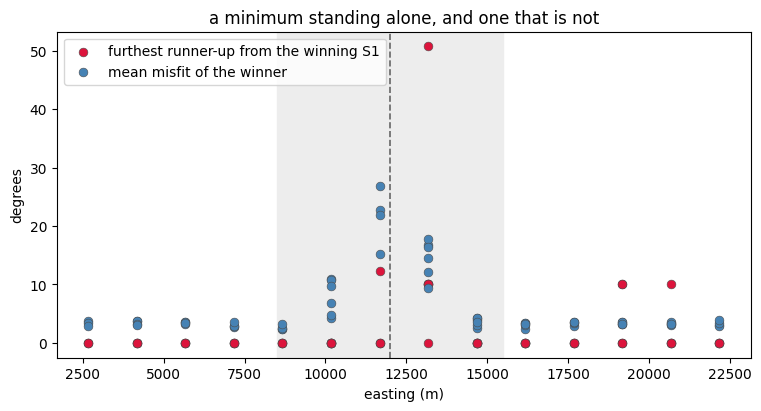

node with the widest runner-up spread: [13172.49022707 14166.11286501]
  S1                 0 / 0
  misfit             16.4 degrees
  best runner-up     16.4 degrees
  furthest runner-up 51 degrees away
  support            12.2 of 24 faults in reach


In [9]:
order = np.argsort(easting)

fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
ax.scatter(easting, field["runner_up_s1_degrees"][inverted],
           s=40, color="crimson", edgecolor="0.3", linewidth=0.4,
           label="furthest runner-up from the winning S1")
ax.scatter(easting, field["misfit_degrees"][inverted],
           s=40, color="steelblue", edgecolor="0.3", linewidth=0.4,
           label="mean misfit of the winner")
ax.axvline(BOUNDARY, color="0.4", ls="--", lw=1.2)
ax.axvspan(BOUNDARY - BANDWIDTH, BOUNDARY + BANDWIDTH, color="0.93", zorder=0)
ax.set_xlabel("easting (m)")
ax.set_ylabel("degrees")
ax.legend()
ax.set_title("a minimum standing alone, and one that is not")
plt.show()

worst = np.flatnonzero(inverted)[np.argmax(field["runner_up_s1_degrees"][inverted])]
print("node with the widest runner-up spread:", field["positions"][worst])
print(f"  S1                 {field['s1'][worst][0]:.0f} / {field['s1'][worst][1]:.0f}")
print(f"  misfit             {field['misfit_degrees'][worst]:.1f} degrees")
print(f"  best runner-up     {field['runner_up_misfit_degrees'][worst]:.1f} degrees")
print(f"  furthest runner-up {field['runner_up_s1_degrees'][worst]:.0f} degrees away")
print(f"  support            {field['support'][worst]:.1f} of "
      f"{field['faults_within_reach'][worst]} faults in reach")

Where both numbers are large at once — a mediocre misfit *and* a
runner-up far away that fits about as well — the node is not a tensor with a
large uncertainty. It is two tensors being averaged, and the honest response is
to say so rather than to plot the average.

## Holes, and why they are left as holes

`min_support` is the effective sample size below which a node is left without a
tensor. Zero inverts wherever a single fault reaches, which is almost never
what is wanted: four parameters are being estimated, so a node held up by three
faults' worth of weight has a solution in the sense that the search returns one
and in no other sense.

Nodes below the threshold keep their density and their count. That is what
makes a thin patch legible instead of blank.

In [10]:
for threshold in [0.0, 12.0, 40.0]:

    _, s = stress_field(positions, faults, grid["origin"], grid["spacing"],
                        grid["counts"], [BANDWIDTH] * 2, min_support=threshold)

    print(f"min_support {threshold:5.0f}:  {s['nodes_inverted']:3d} inverted, "
          f"{s['nodes_below_threshold']:3d} below threshold, "
          f"{s['nodes_without_data']:3d} with no data at all")

min_support     0:  194 inverted,   0 below threshold,  91 with no data at all


min_support    12:   64 inverted, 130 below threshold,  91 with no data at all
min_support    40:    0 inverted, 194 below threshold,  91 with no data at all


## Density fine, stress coarse

Both grids are yours to choose, and they should not be the same one. A node's
density costs microseconds; a node's tensor costs a fraction of a second and
tens of thousands of candidate tensors. On the run this library's figures were
measured against, a node took about 350 ms to invert against microseconds for
the density at that same node.

So run `density_field` on a fine grid, run `stress_field` on a coarse one, and
put the first underneath the second — which is what the map above does. The
`density` column of the stress field is there so the two are guaranteed to be
the same estimator, not so it has to be the one you look at.

## Threads

`stress_field` and `density_field` use every core available, with the
interpreter released for the duration, and the result does not depend on how
many cores that was — **bit for bit**. The parallelism is over nodes, each
node's arithmetic stays sequential inside it, and no accumulator is ever
shared, so there is no partial-sum order for the thread count to change.

To bound the pool — inside a plugin that must leave its host responsive — set
`RAYON_NUM_THREADS` before the first call. On the four-core laptop these
figures were measured on, the same field took 7.54 s at one thread, 3.73 s at
two and 1.51 s unbounded, with 6.66 threads' worth of CPU consumed in the last
case. The shortfall against eight is the machine, not the split: it is a 15 W
part running its all-core clock well below its single-core turbo, with two
hardware threads to each physical core.

## What to carry away

- A single inversion assumes one tensor explains everything. **Check that
  assumption before trusting the answer**; the runners-up are the cheap way.
- **`field_cost` first.** It is milliseconds and it tells you whether the run
  is seconds or days.
- **Read `support`, not `faults_within_reach`.** They differ most exactly where
  you are most tempted to over-read the map.
- **Read `runner_up_s1_degrees` beside the misfit.** It is what distinguishes a
  well-determined tensor from an average of two.
- **Leave the holes.** A node without enough data is information; filled in, it
  is decoration.